In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/georgejdinicola/world-bank-indicators/energy_mining.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/agriculture_rural_development.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/private_sector.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/infrastructure.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/economy_growth.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/poverty.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/social_protection_labor.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/public_sector.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/aid_effectiveness.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/environment.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/world_bank_indicators.csv
/kaggle/input/datasets/georgejdinicola/world-bank-indicators/urban_development.csv
/kaggle/input/d

In [2]:
# Load and inspect the main dataset
df = pd.read_csv('/kaggle/input/datasets/georgejdinicola/world-bank-indicators/economy_growth.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (15720, 104)

Columns: ['year', 'country', 'Communications, computer, etc. (% of service imports, BoP)', 'Primary income payments (BoP, current US$)', 'Service imports (BoP, current US$)', 'Transport services (% of service imports, BoP)', 'Foreign direct investment, net outflows (% of GDP)', 'Secondary income, other sectors, payments (BoP, current US$)', 'ICT service exports (% of service exports, BoP)', 'Primary income receipts (BoP, current US$)', 'Transport services (% of service exports, BoP)', 'Foreign direct investment, net inflows (% of GDP)', 'Secondary income receipts (BoP, current US$)', 'Personal remittances, received (% of GDP)', 'Net official development assistance received (current US$)', 'Net ODA received (% of GNI)', 'Net ODA received per capita (current US$)', 'Revenue, excluding grants (% of GDP)', 'Expense (% of GDP)', 'General government final consumption expenditure (current US$)', 'General government final consumption expenditure (constant 2015 US$)', 'Gene

,year,country,"Communications, computer, etc. (% of service imports, BoP)","Primary income payments (BoP, current US$)","Service imports (BoP, current US$)","Transport services (% of service imports, BoP)","Foreign direct investment, net outflows (% of GDP)","Secondary income, other sectors, payments (BoP, current US$)","ICT service exports (% of service exports, BoP)","Primary income receipts (BoP, current US$)",...,GNI growth (annual %),"GNI, PPP (current international $)","GNI, PPP (constant 2021 international $)","GNI per capita, Atlas method (current US$)",GNI per capita (constant 2015 US$),GNI per capita growth (annual %),"GNI per capita, PPP (current international $)","GNI per capita, PPP (constant 2021 international $)",Gross savings (% of GNI),Gross savings (% of GDP)
0,1960,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1960,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1960,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1960,ARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


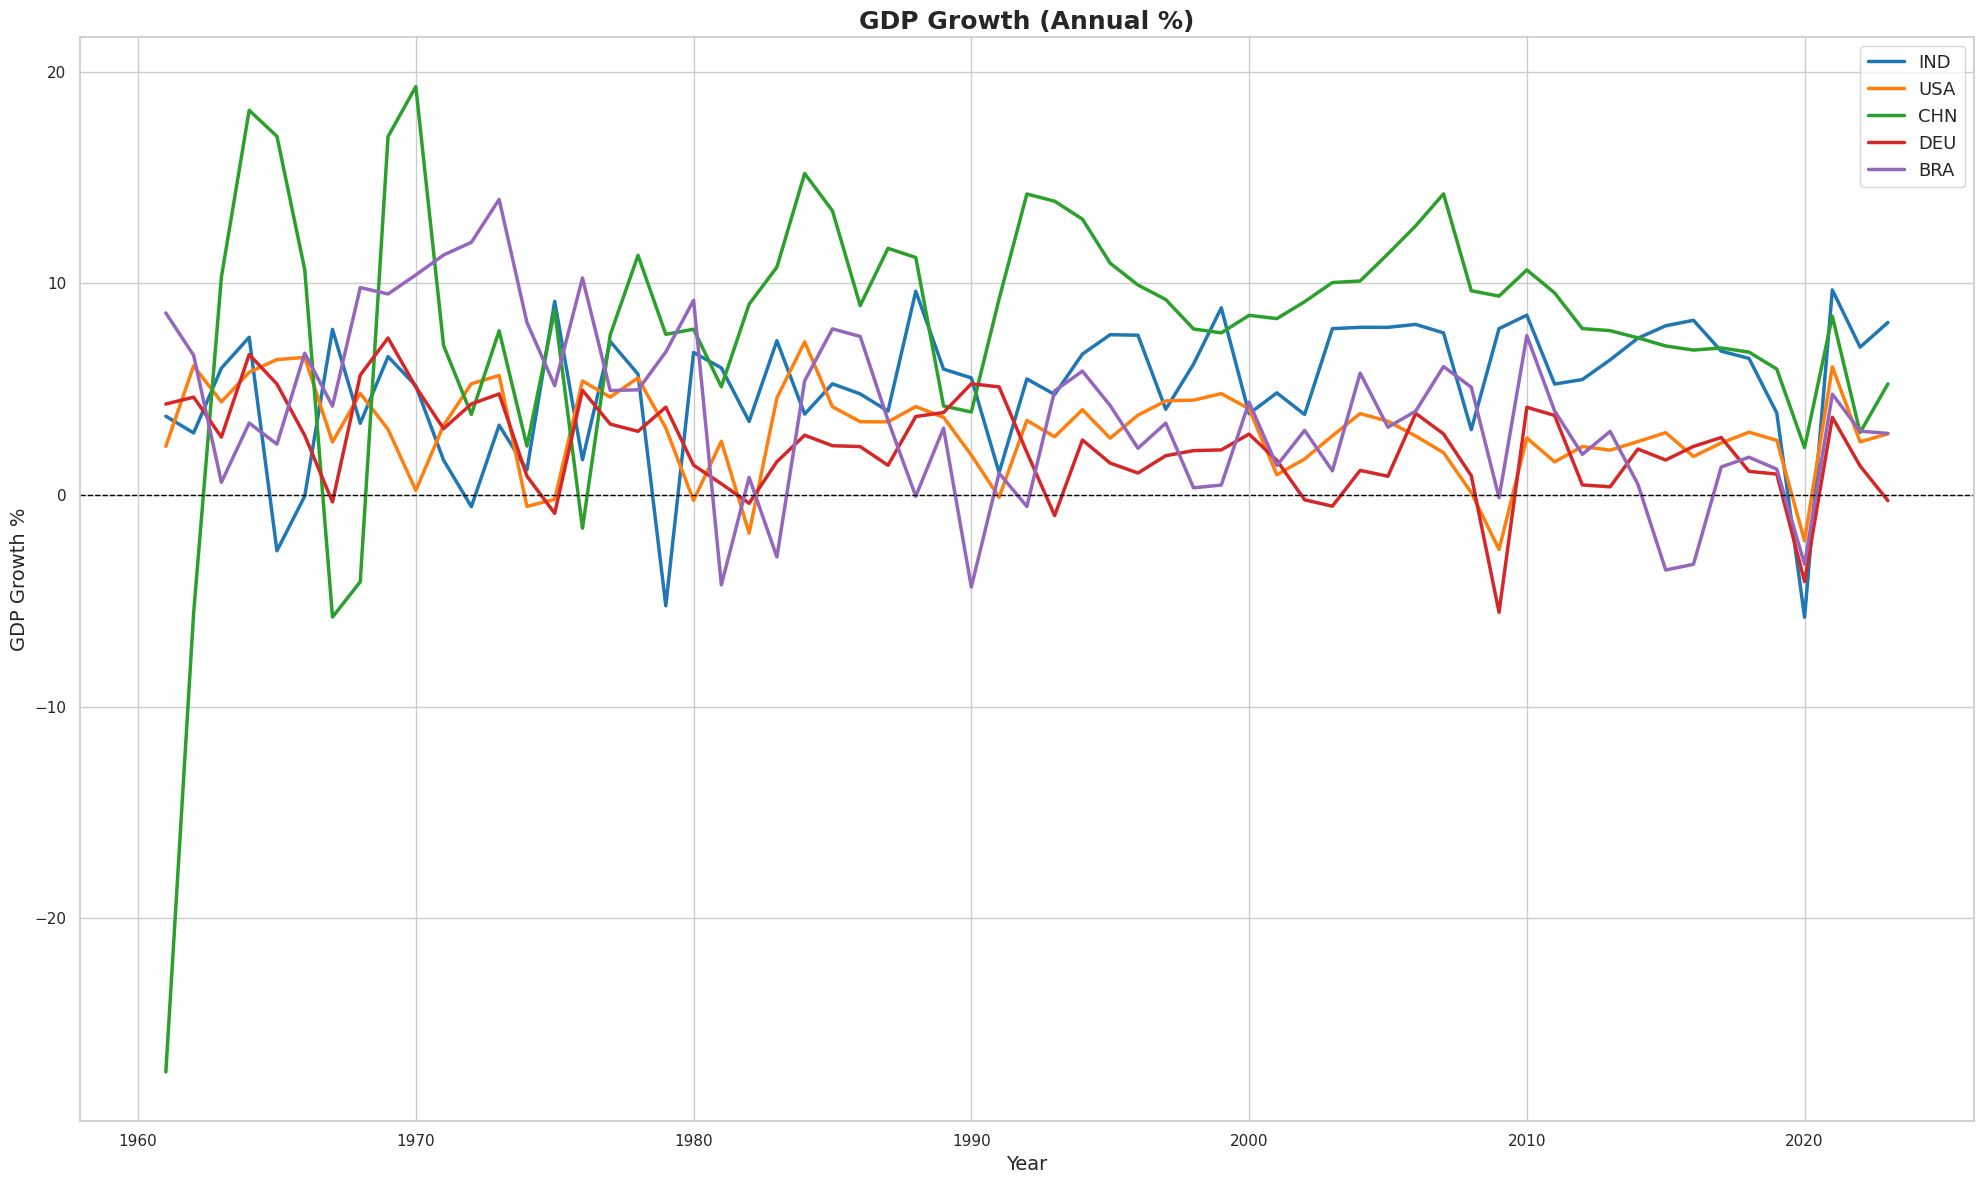

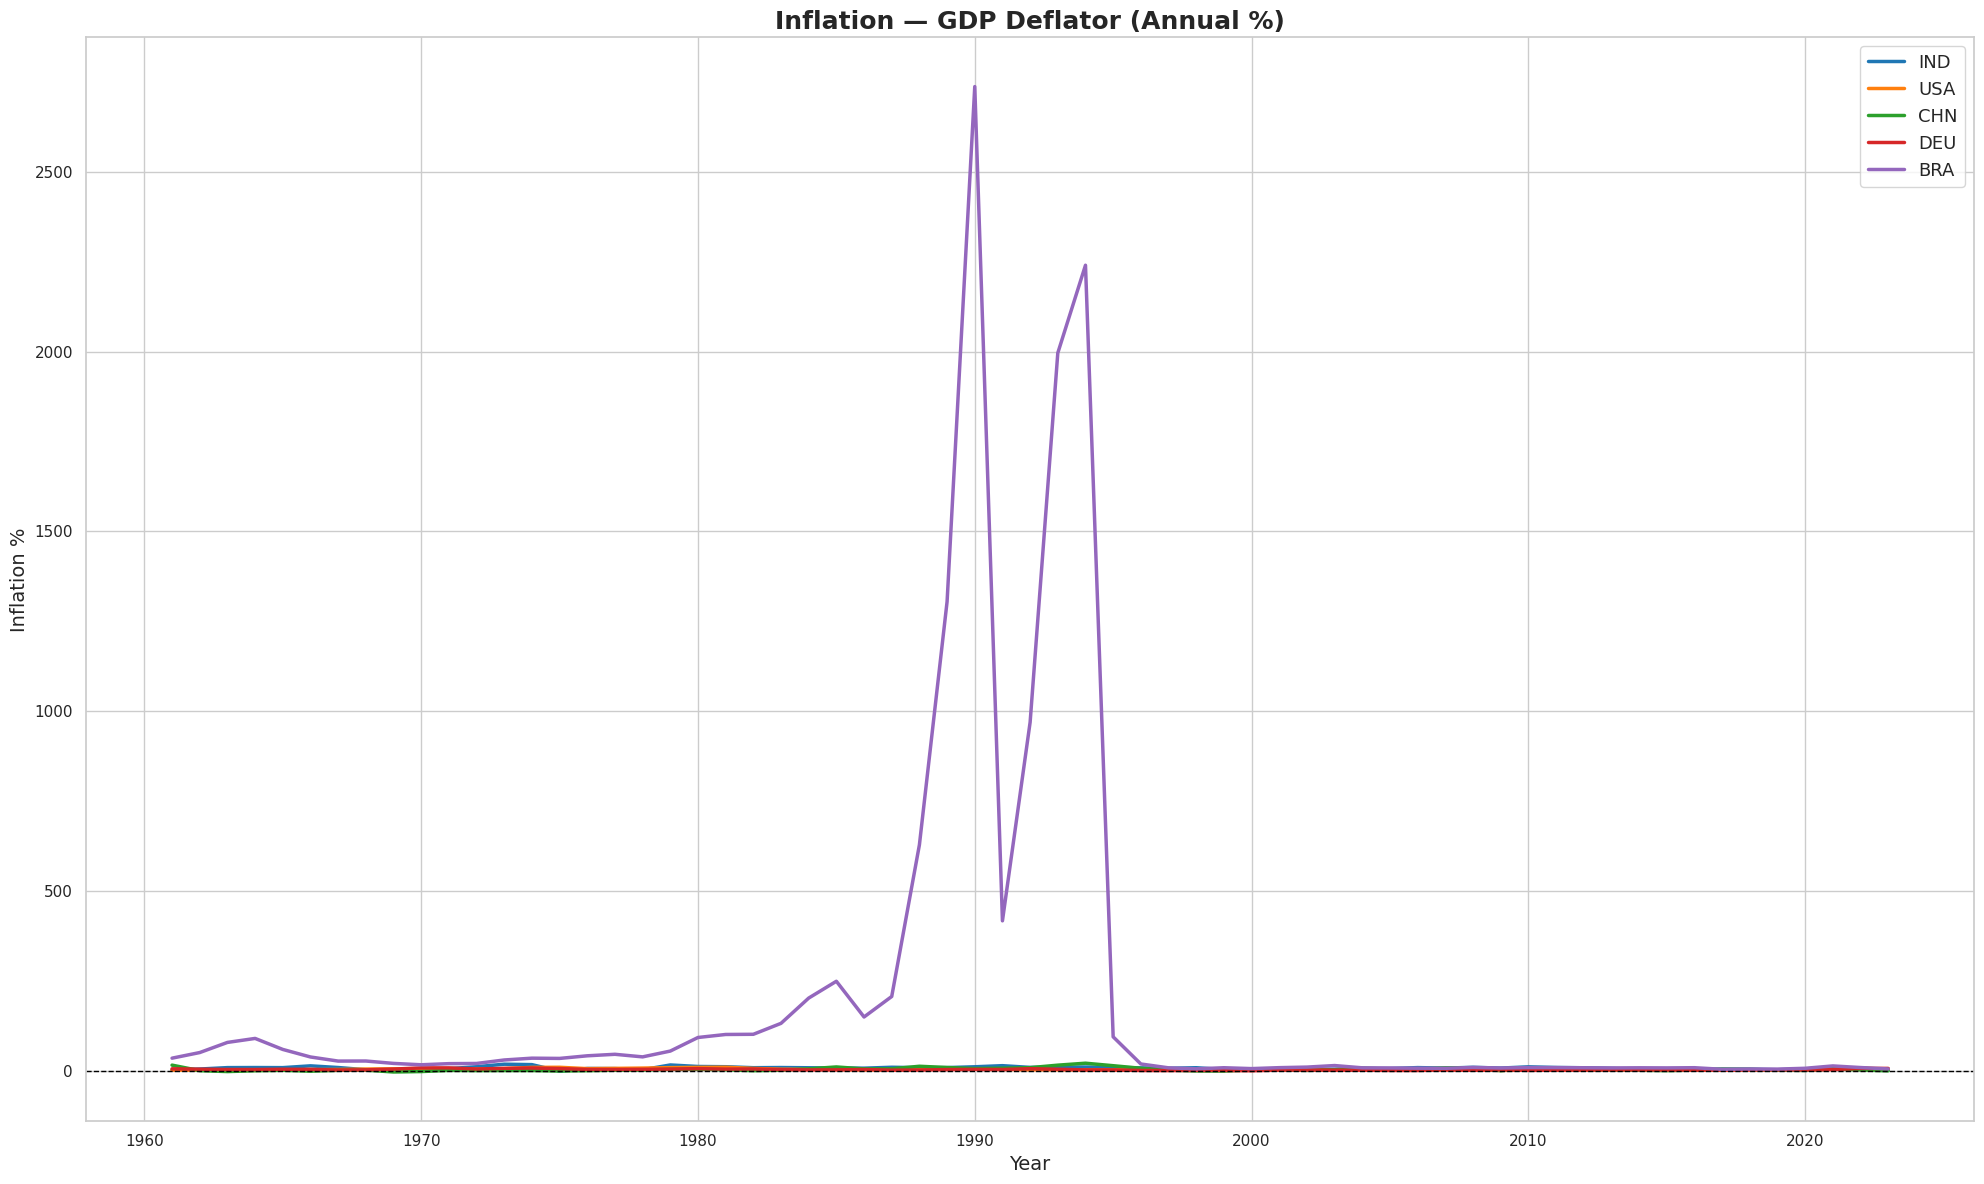

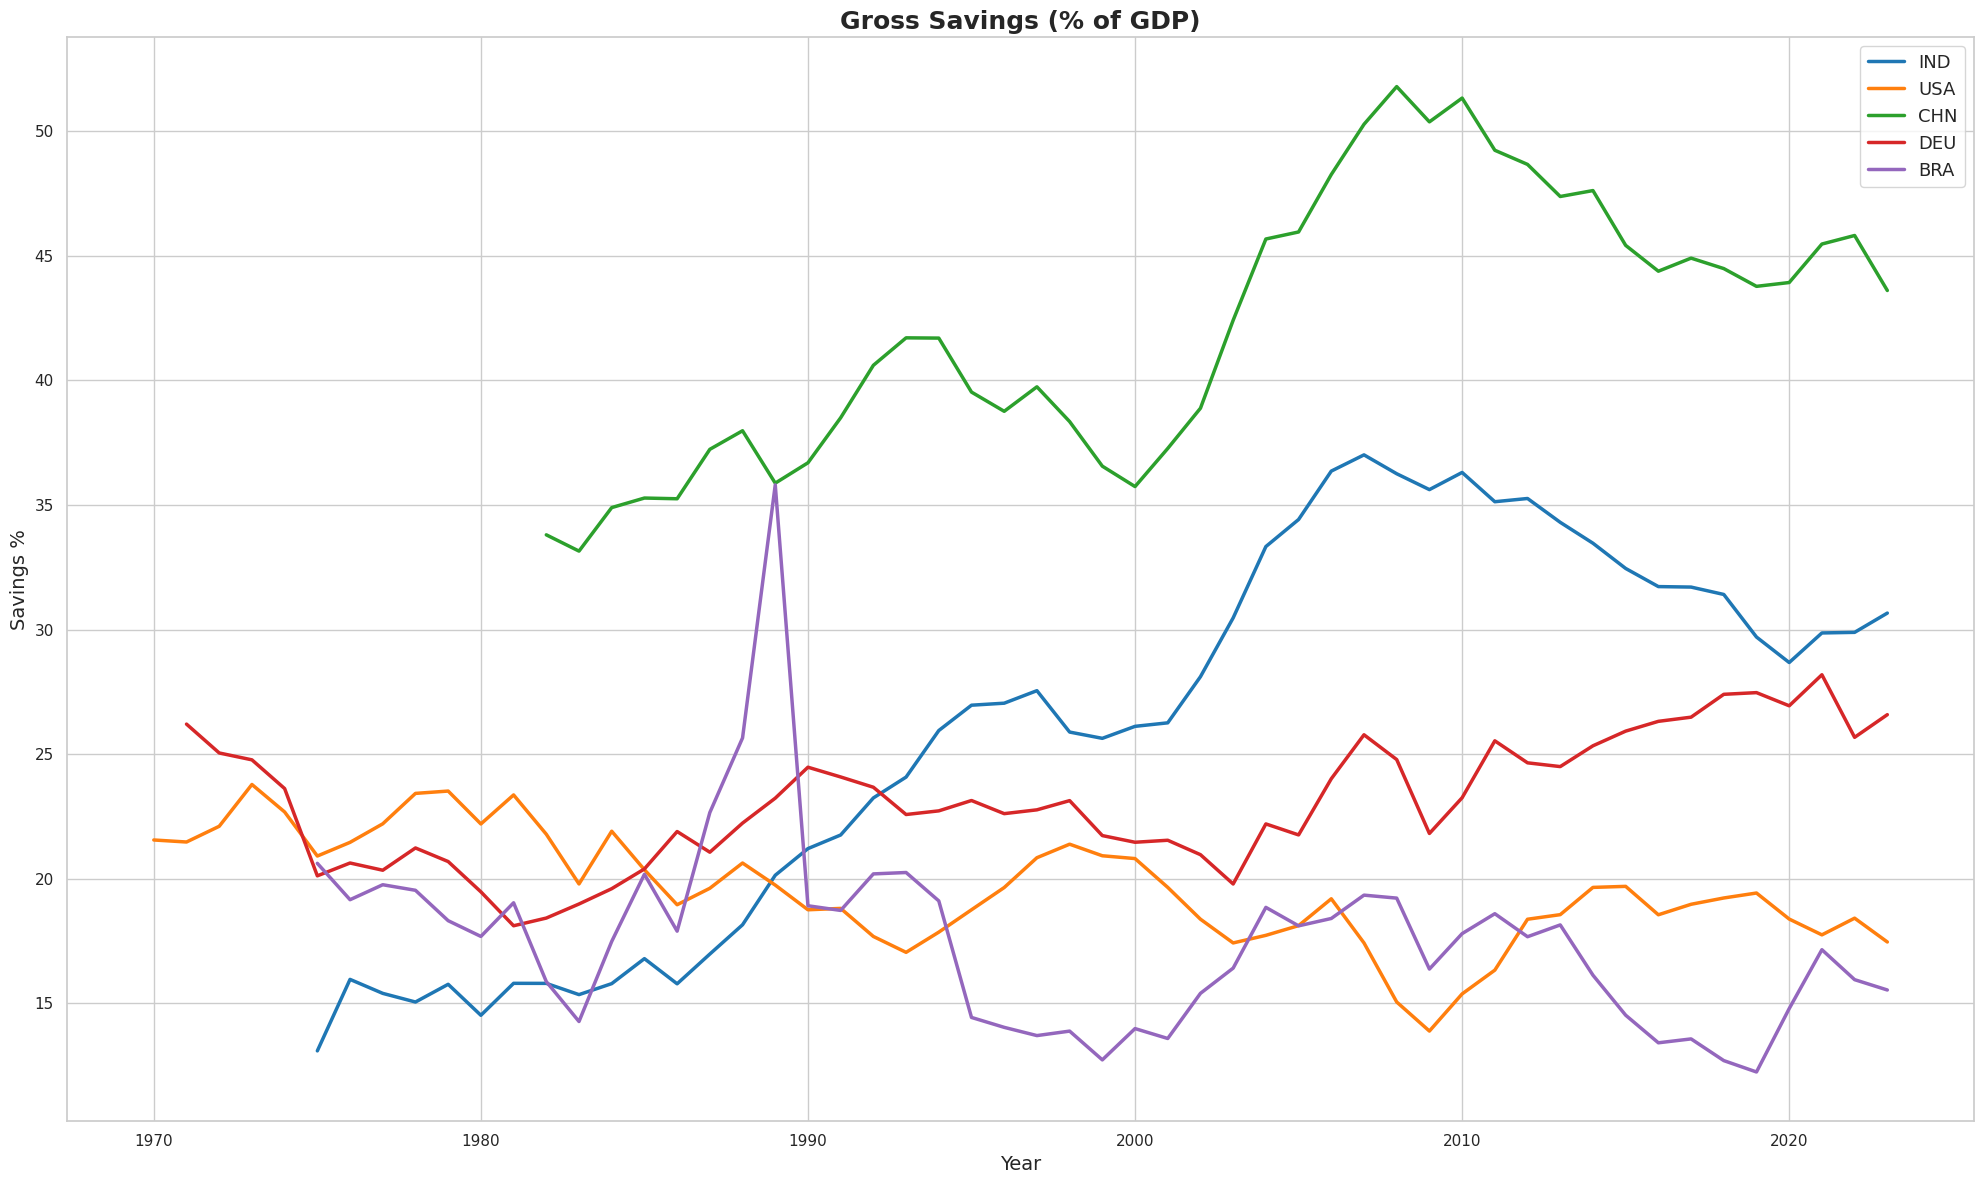

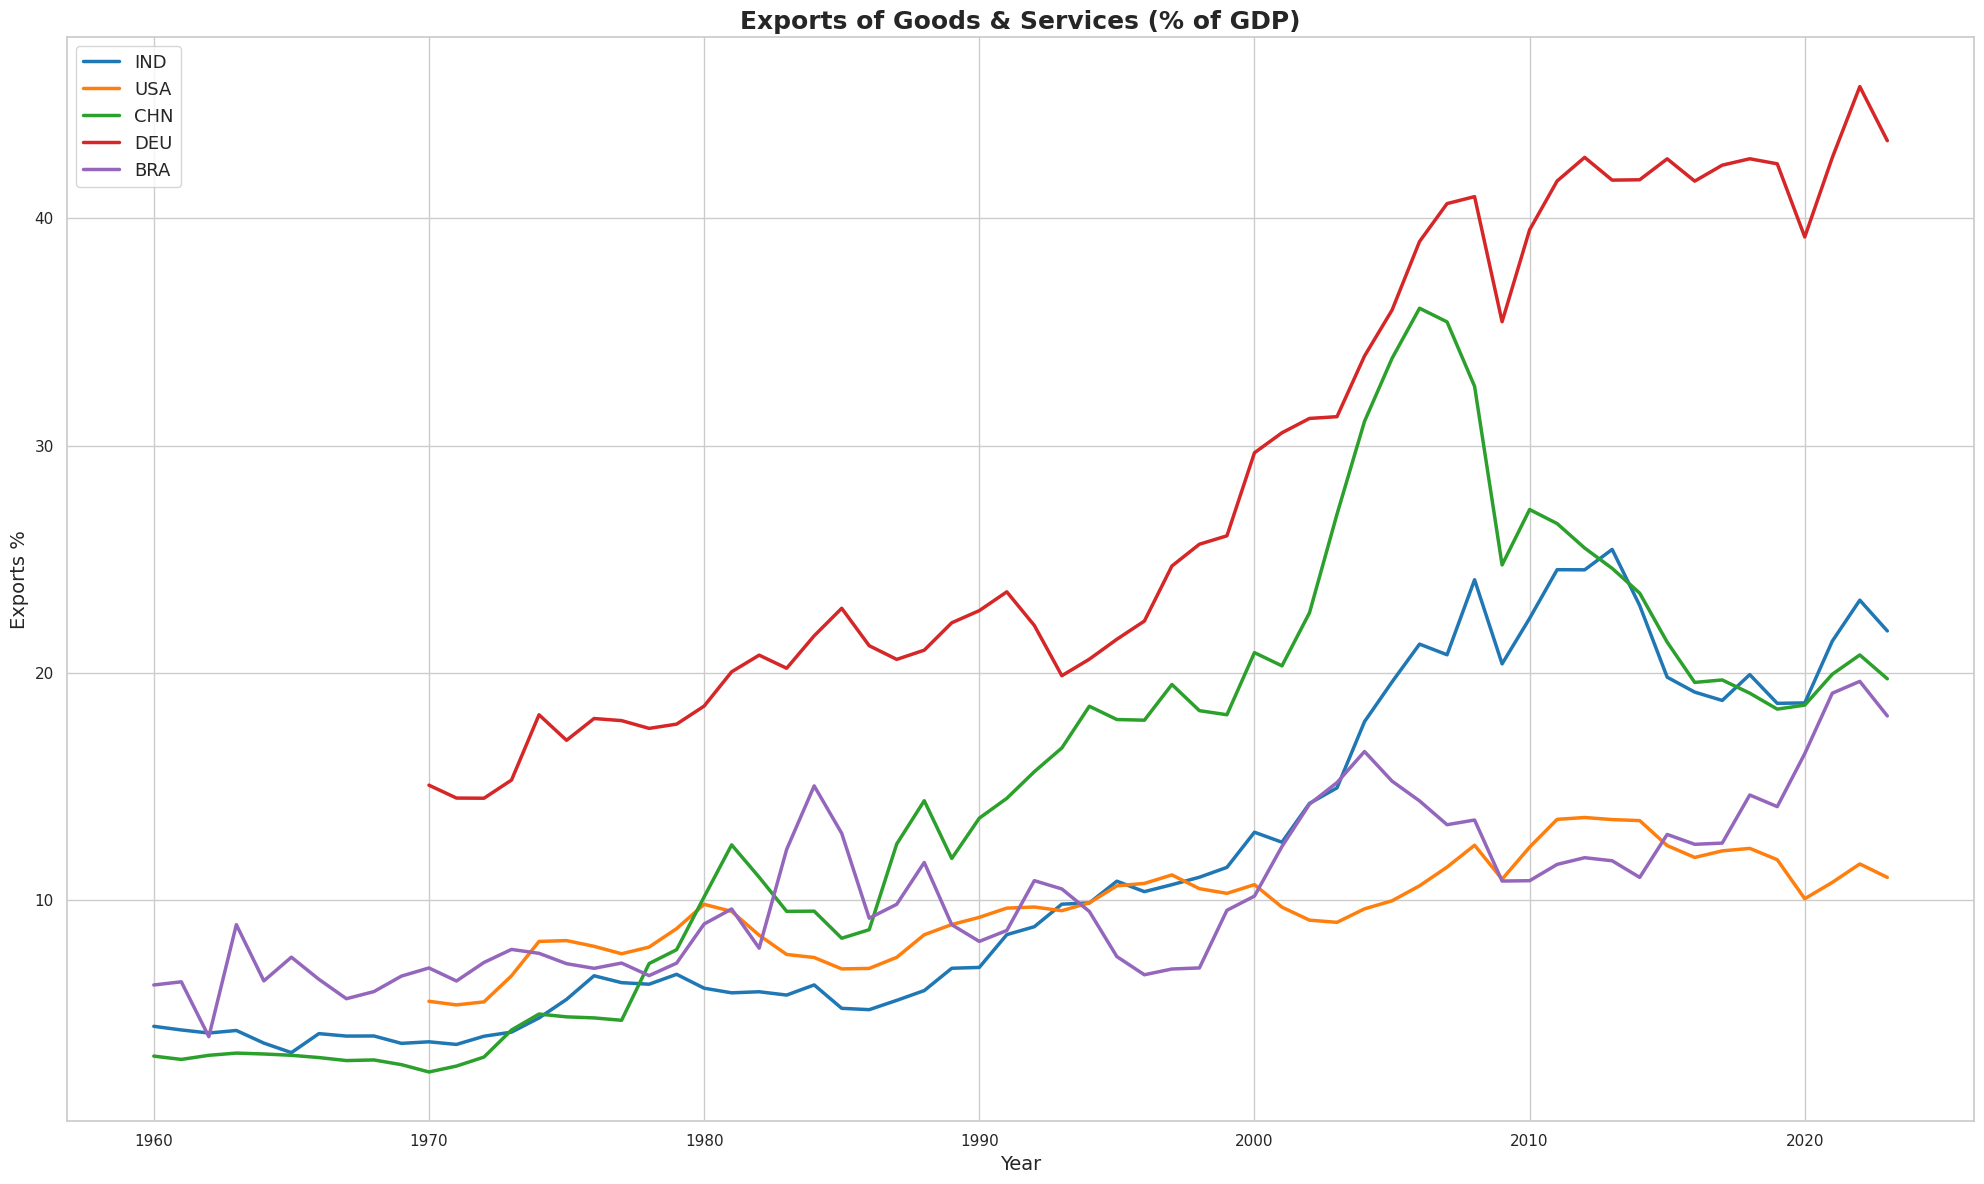

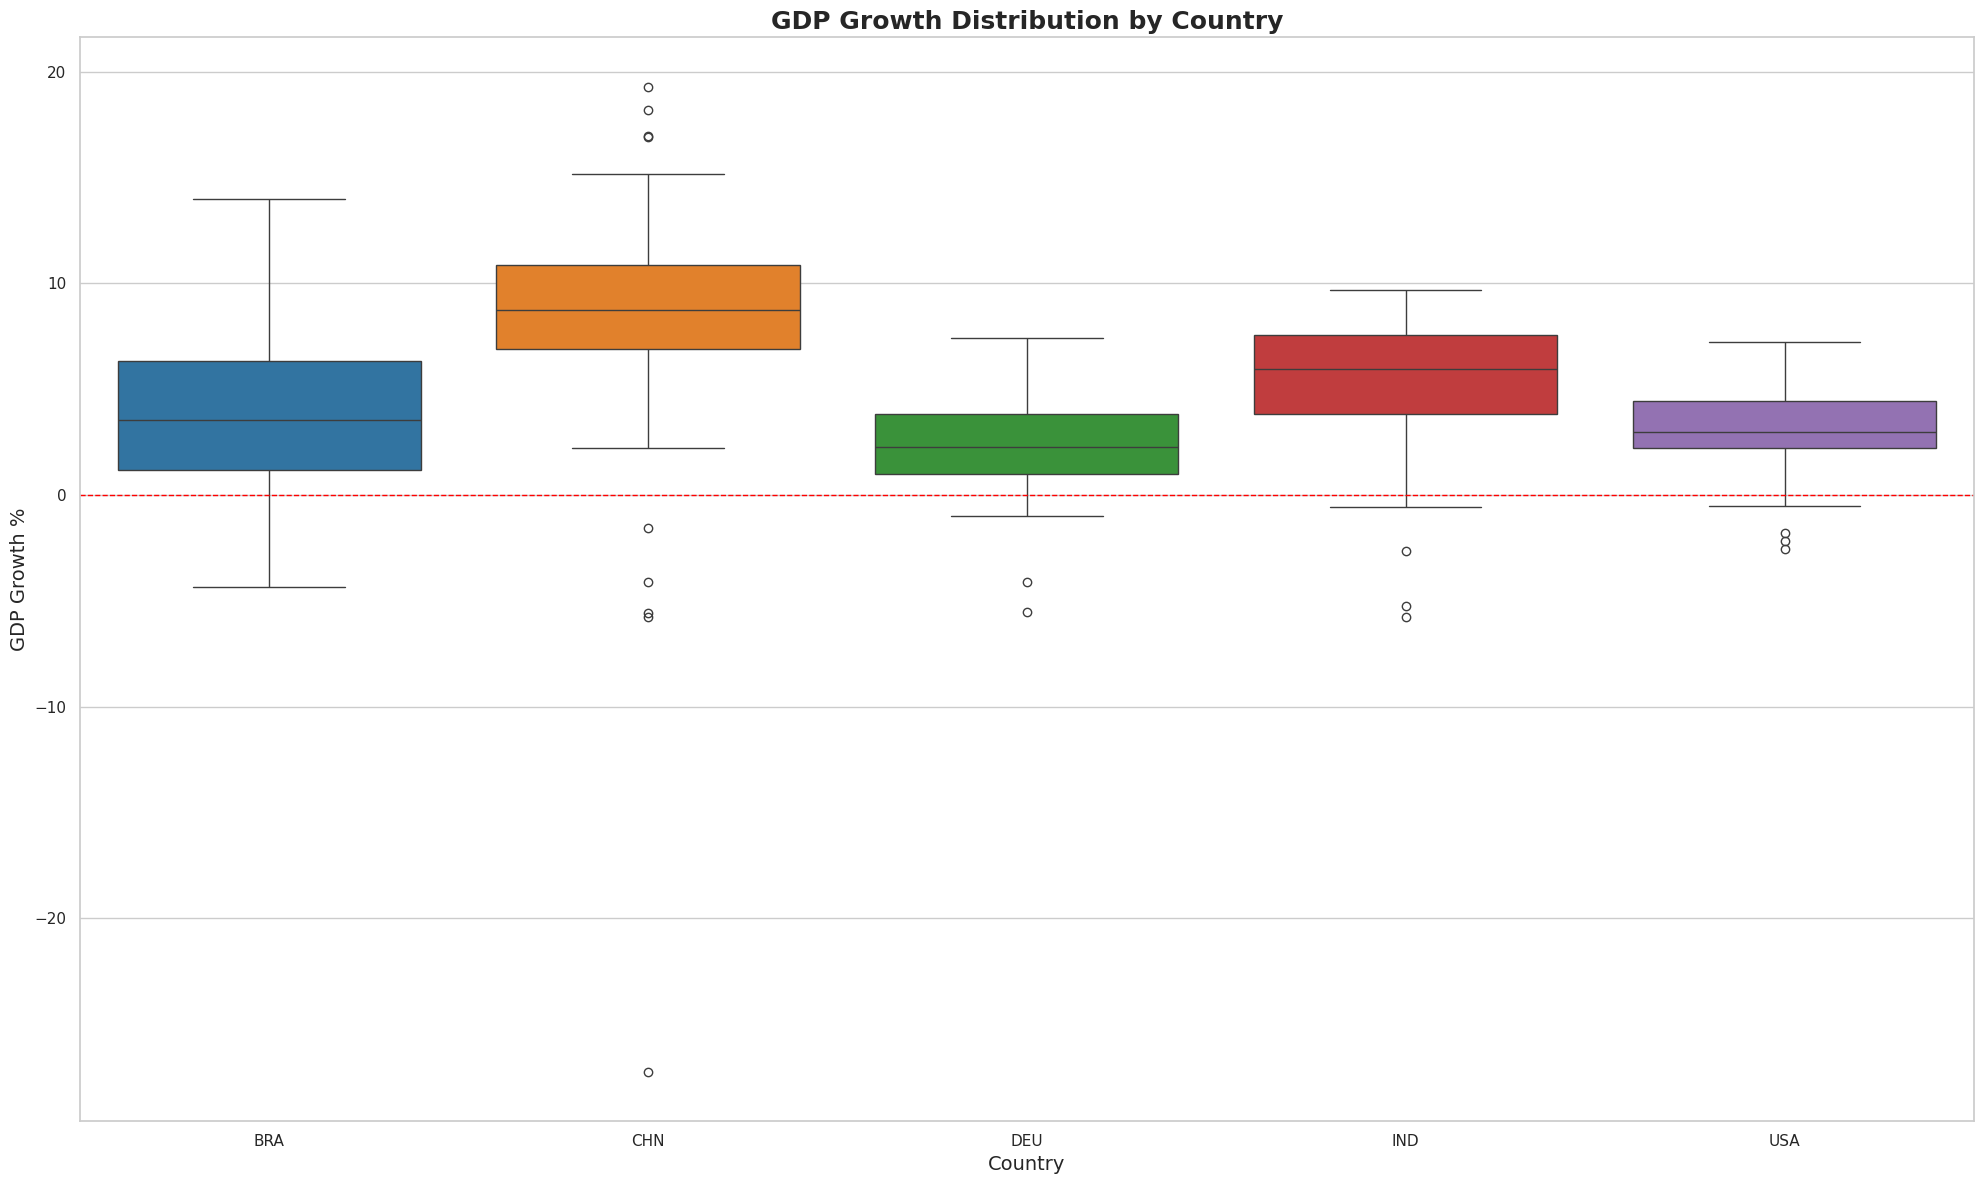

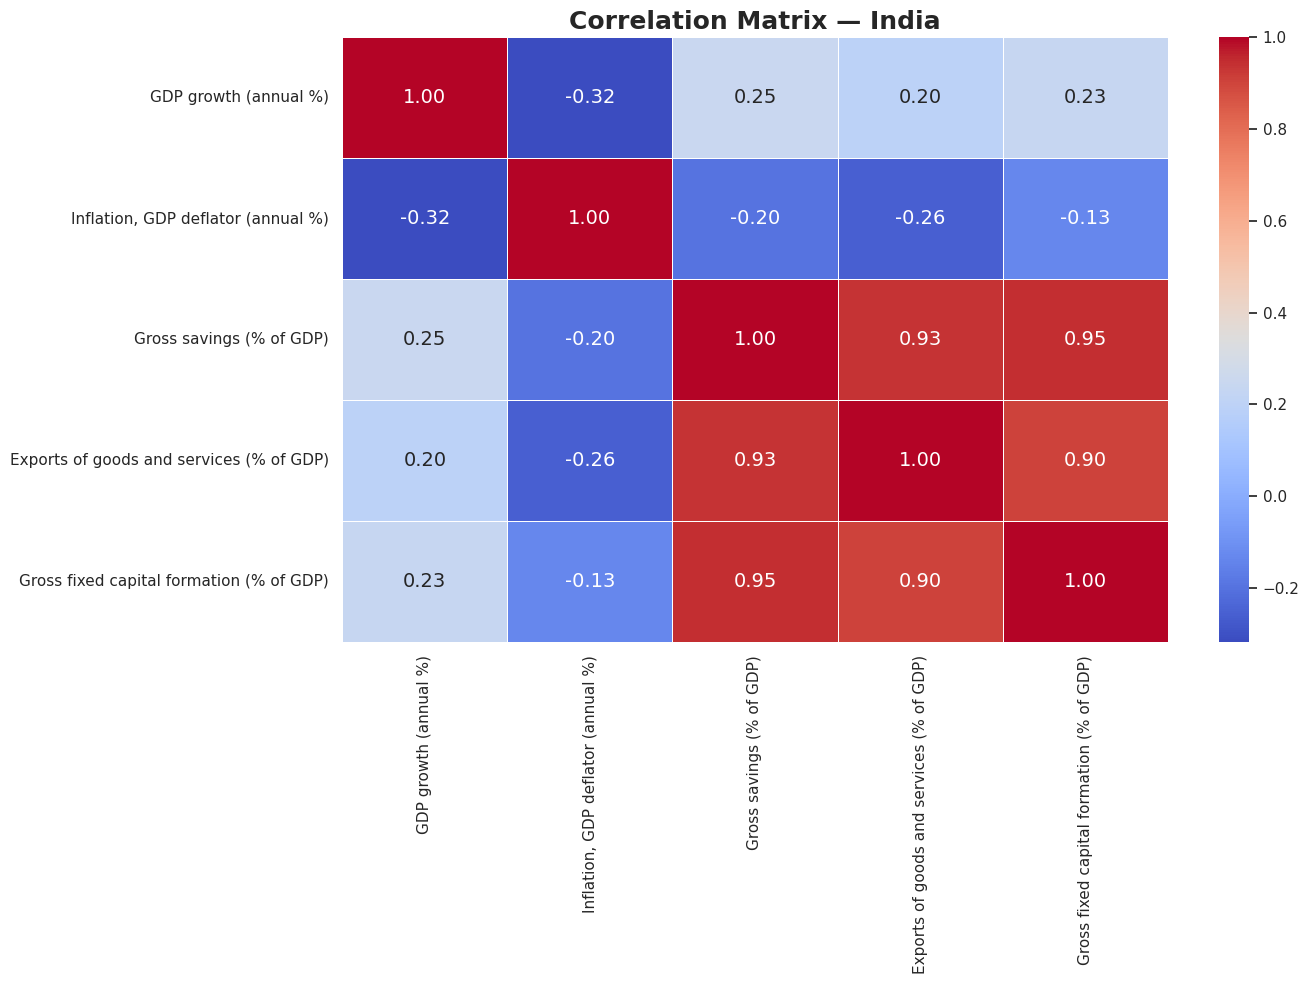

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
countries = ['IND', 'USA', 'CHN', 'DEU', 'BRA']
cols = ['year', 'country', 'GDP growth (annual %)', 
        'Inflation, GDP deflator (annual %)',
        'Gross fixed capital formation (% of GDP)',
        'Exports of goods and services (% of GDP)',
        'Gross savings (% of GDP)']

df_focus = df[df['country'].isin(countries)][cols].dropna(subset=['GDP growth (annual %)'])
df_inf    = df[df['country'].isin(countries)][['year','country','Inflation, GDP deflator (annual %)']].dropna()
df_sav    = df[df['country'].isin(countries)][['year','country','Gross savings (% of GDP)']].dropna()
df_exp    = df[df['country'].isin(countries)][['year','country','Exports of goods and services (% of GDP)']].dropna()
plot_data = df_focus[['country','GDP growth (annual %)']].dropna()
df_ind    = df[df['country'] == 'IND'][['GDP growth (annual %)',
              'Inflation, GDP deflator (annual %)',
              'Gross savings (% of GDP)',
              'Exports of goods and services (% of GDP)',
              'Gross fixed capital formation (% of GDP)']].dropna()

sns.set_theme(style='whitegrid', palette='tab10')

# Plot 1 — GDP Growth
fig, ax = plt.subplots(figsize=(20, 12))
for c in countries:
    d = df_focus[df_focus['country'] == c]
    ax.plot(d['year'], d['GDP growth (annual %)'], label=c, linewidth=2.5)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('GDP Growth (Annual %)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('GDP Growth %', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Plot 2 — Inflation
fig, ax = plt.subplots(figsize=(20, 12))
for c in countries:
    d = df_inf[df_inf['country'] == c]
    ax.plot(d['year'], d['Inflation, GDP deflator (annual %)'], label=c, linewidth=2.5)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Inflation — GDP Deflator (Annual %)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Inflation %', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Plot 3 — Gross Savings
fig, ax = plt.subplots(figsize=(20, 12))
for c in countries:
    d = df_sav[df_sav['country'] == c]
    ax.plot(d['year'], d['Gross savings (% of GDP)'], label=c, linewidth=2.5)
ax.set_title('Gross Savings (% of GDP)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Savings %', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Plot 4 — Exports
fig, ax = plt.subplots(figsize=(20, 12))
for c in countries:
    d = df_exp[df_exp['country'] == c]
    ax.plot(d['year'], d['Exports of goods and services (% of GDP)'], label=c, linewidth=2.5)
ax.set_title('Exports of Goods & Services (% of GDP)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Exports %', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Plot 5 — Boxplot
fig, ax = plt.subplots(figsize=(20, 12))
sns.boxplot(data=plot_data, x='country', y='GDP growth (annual %)',
            hue='country', palette='tab10', legend=False, ax=ax)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_title('GDP Growth Distribution by Country', fontsize=18, fontweight='bold')
ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('GDP Growth %', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 6 — Correlation Heatmap India
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df_ind.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, annot_kws={"size": 14})
ax.set_title('Correlation Matrix — India', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# SECTION 2 — SUPERVISED LEARNING
# Goal: Predict next year's GDP growth using current economic indicators

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Features we'll use to predict GDP growth
features = [
    'Inflation, GDP deflator (annual %)',
    'Gross savings (% of GDP)',
    'Exports of goods and services (% of GDP)',
    'Gross fixed capital formation (% of GDP)',
    'Imports of goods and services (% of GDP)'
]
target = 'GDP growth (annual %)'

# Use all 5 countries combined — more data = better model
all_cols = ['year', 'country'] + features + [target]
df_ml = df[df['country'].isin(countries)][all_cols].dropna()

print("Dataset shape after dropping NaNs:", df_ml.shape)
print("\nCountry-wise row count:")
print(df_ml['country'].value_counts())
print("\nSample:")
df_ml.head()

Dataset shape after dropping NaNs: (247, 8)

Country-wise row count:
country
USA    54
DEU    53
BRA    49
IND    49
CHN    42
Name: count, dtype: int64

Sample:


,year,country,"Inflation, GDP deflator (annual %)",Gross savings (% of GDP),Exports of goods and services (% of GDP),Gross fixed capital formation (% of GDP),Imports of goods and services (% of GDP),GDP growth (annual %)
2155,1970,USA,5.262728,21.559429,5.563108,10.411226,5.195178,0.216606
2220,1971,DEU,7.621336,26.208519,14.499342,29.947914,16.227566,3.132700
2407,1971,USA,5.069808,21.478302,5.405245,11.228227,5.351934,3.292722
2472,1972,DEU,4.531857,25.050732,14.492268,29.286932,16.123980,4.300341
2659,1972,USA,4.326127,22.108810,5.538460,21.868643,5.802159,5.255502


In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Features and target
features = [
    'Inflation, GDP deflator (annual %)',
    'Gross savings (% of GDP)',
    'Exports of goods and services (% of GDP)',
    'Gross fixed capital formation (% of GDP)',
    'Imports of goods and services (% of GDP)'
]
target = 'GDP growth (annual %)'

# Data prep
countries = ['IND', 'USA', 'CHN', 'DEU', 'BRA']
all_cols = ['year', 'country'] + features + [target]
df_ml = df[df['country'].isin(countries)][all_cols].dropna()

X = df_ml[features]
y = df_ml[target]

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Models
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(alpha=1.0),
    'Lasso'              : Lasso(alpha=0.1),
    'ElasticNet'         : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'            : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'SVR'                : SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN'                : KNeighborsRegressor(n_neighbors=5)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse  = rmse  = mean_squared_error(y_test, preds) ** 0.5
    r2    = r2_score(y_test, preds)
    results[name] = {'RMSE': round(rmse, 3), 'R²': round(r2, 3)}

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("Model Comparison:")
print(results_df)

Model Comparison:
                    RMSE     R²
SVR                2.312  0.545
Linear Regression  2.385  0.515
Ridge              2.395  0.511
Lasso              2.433  0.495
ElasticNet         2.445  0.491
Gradient Boosting  2.545  0.448
KNN                2.597  0.425
Random Forest      2.616  0.417
XGBoost            2.815  0.325
Decision Tree      3.010  0.228


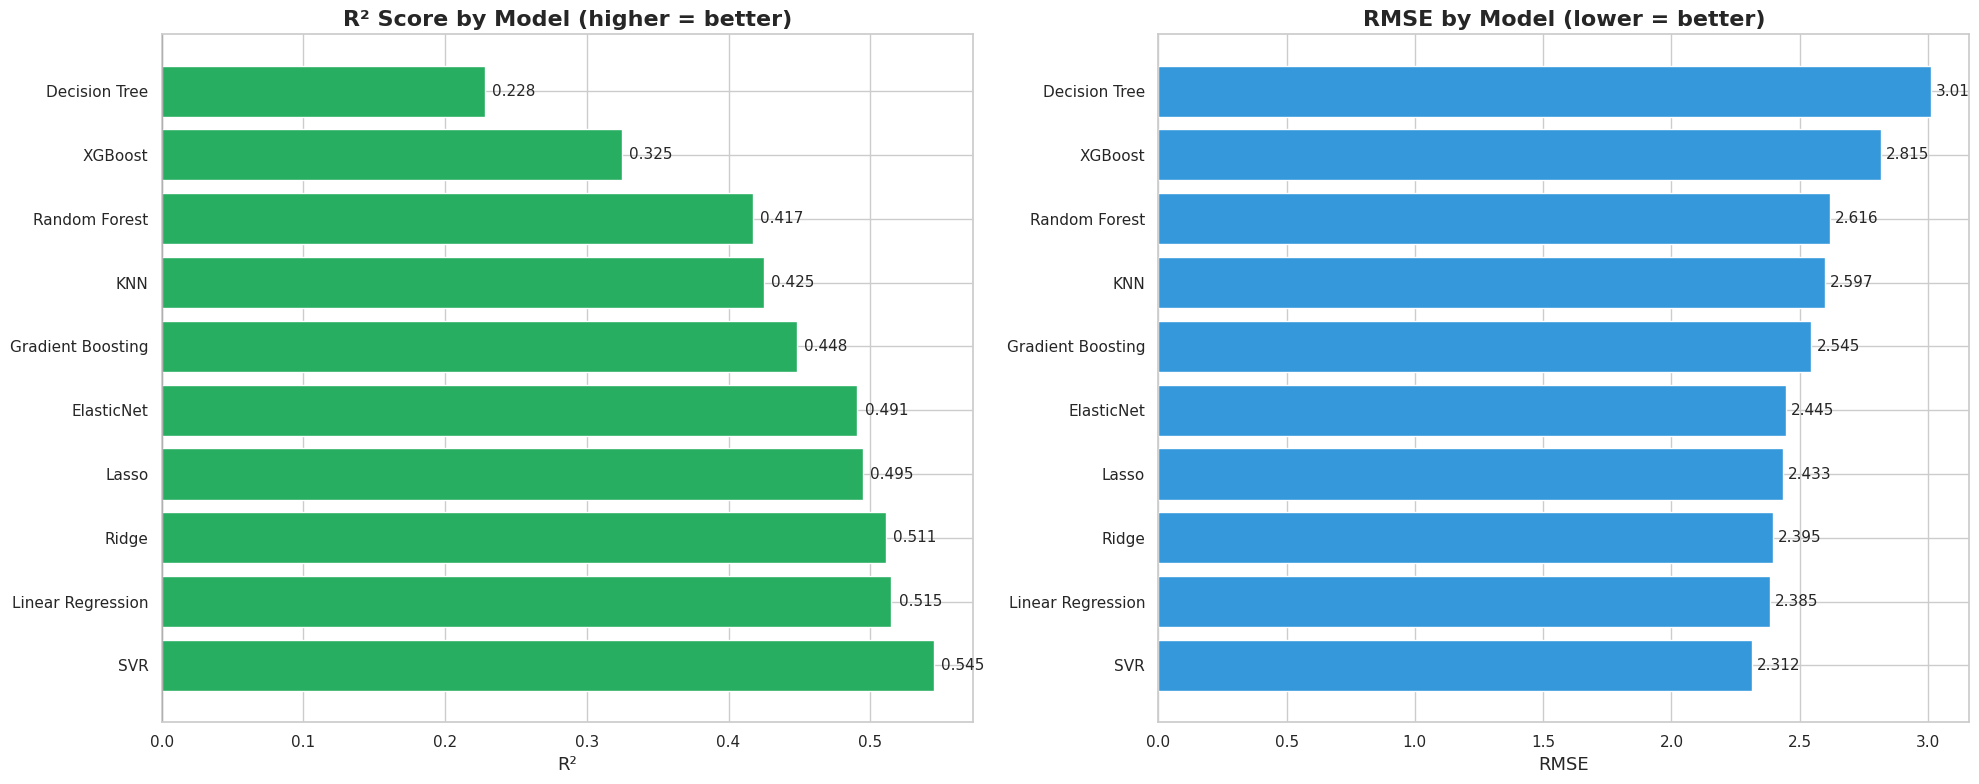

In [6]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# R² Score
colors_r2 = ['#27ae60' if v > 0 else '#e74c3c' for v in results_df['R²']]
axes[0].barh(results_df.index, results_df['R²'], color=colors_r2)
axes[0].set_title('R² Score by Model (higher = better)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('R²', fontsize=13)
axes[0].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.02, i, str(v), va='center', fontsize=11)

# RMSE
axes[1].barh(results_df.index, results_df['RMSE'], color='#3498db')
axes[1].set_title('RMSE by Model (lower = better)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('RMSE', fontsize=13)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 0.02, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()

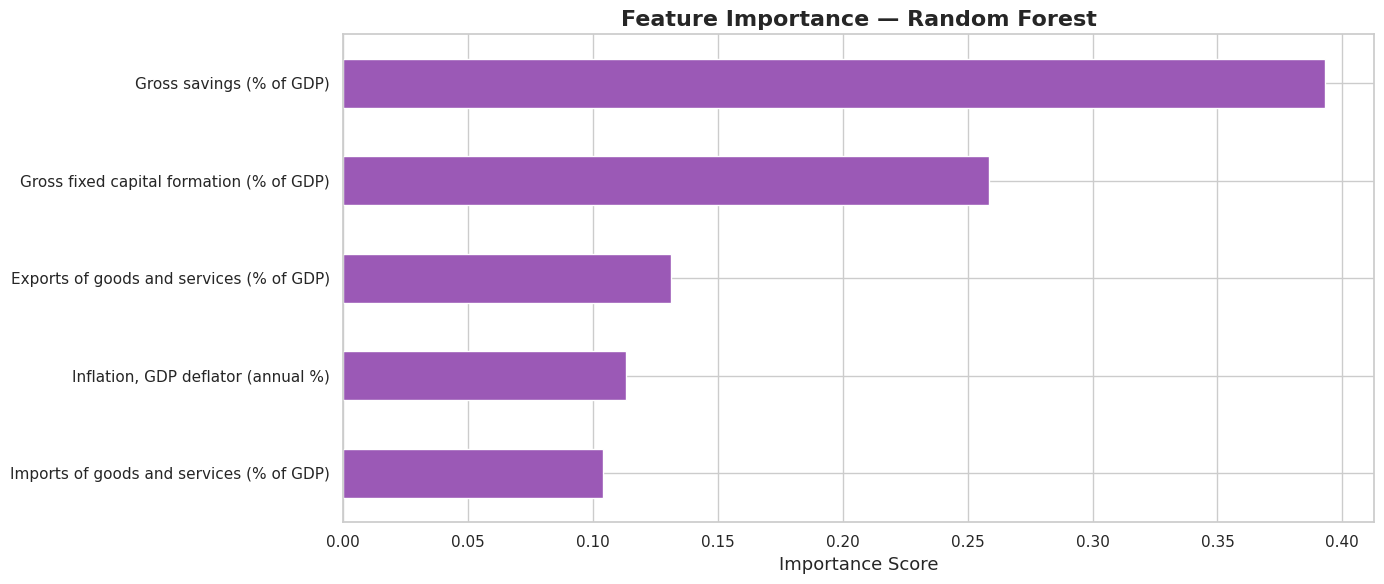

In [7]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
importances.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_title('Feature Importance — Random Forest', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=13)
plt.tight_layout()
plt.show()

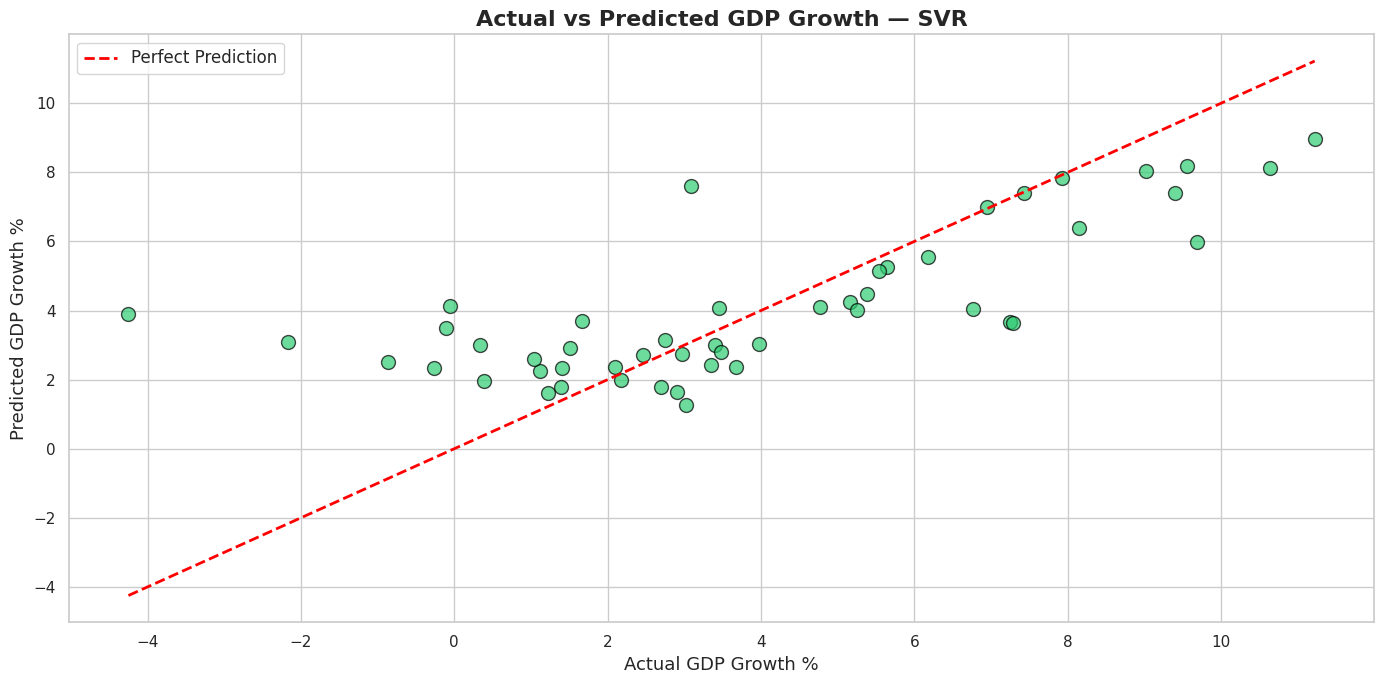


Best model: SVR
R² score: 0.545
RMSE: 2.312


In [8]:
# Actual vs Predicted — best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]
preds_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(y_test, preds_best, alpha=0.7, color='#2ecc71', edgecolors='black', s=100)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted GDP Growth — {best_model_name}', fontsize=16, fontweight='bold')
ax.set_xlabel('Actual GDP Growth %', fontsize=13)
ax.set_ylabel('Predicted GDP Growth %', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"R² score: {results_df.loc[best_model_name, 'R²']}")
print(f"RMSE: {results_df.loc[best_model_name, 'RMSE']}")